# Task II

Implements two graph-based architectures for Quark/Gluon jet classification using the ParticleNet dataset.

In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

/Users/lakshi/opt/anaconda3/envs/test-Assignment03/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading and Preprocessing

The ParticleNet dataset contains jet constituents as point clouds. Each jet has particles with features like (eta, phi, pt).

In [4]:
DATA_PATH = "./data/"
os.makedirs(DATA_PATH, exist_ok=True)

data_file = os.path.join(DATA_PATH, "QG_jets.npz")

In [5]:
def load_data(filepath, num_samples=50000):
    """
    Load quark/gluon jet data.
    Returns particle features and labels.
    """
    data = np.load(filepath)
    
    # X: particle features (N_jets, N_particles, N_features)
    # y: labels (0=gluon, 1=quark)
    X = data['X'][:num_samples]
    y = data['y'][:num_samples]
    
    return X, y

In [6]:
# Loading data 
X, y = load_data(data_file)

## 2. Point Cloud to Graph Conversion

### Considerations for Graph Construction:

1. **Node representation**: Each particle in the jet becomes a node with features (eta, phi, pt, etc.)

2. **Edge construction**: I use k-nearest neighbors (k-NN) in the (eta, phi) space. This is physically motivated because:
   - Particles close in (eta, phi) are likely from the same parton shower
   - The angular distance captures the jet's geometric structure
   - k-NN preserves local neighborhood information while keeping the graph sparse

3. **Edge features**: Distance between particles can serve as edge weights

4. **Handling variable-size jets**: Zero-padded particles are masked out during graph construction

In [7]:
def build_graph(particles, k=8):
    """
    Convert particle point cloud to graph using k-NN.
    
    Args:
        particles: (N_particles, N_features) array
        k: number of nearest neighbors
    
    Returns:
        edge_index: (2, num_edges) tensor
        valid_mask: boolean mask for non-zero particles
    """
    # Find non-zero particles (remove padding)
    norms = np.linalg.norm(particles, axis=1)
    valid_mask = norms > 1e-6
    valid_indices = np.where(valid_mask)[0]
    
    if len(valid_indices) < 2:
        # Return empty edges if too few particles
        return np.array([[], []]).astype(np.int64), valid_mask
    
    valid_particles = particles[valid_mask]
    
    # Use first two features (eta, phi) for distance calculation
    coords = valid_particles[:, :2]
    
    # Compute pairwise distances
    n = len(coords)
    k_actual = min(k, n - 1)
    
    dist_matrix = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=-1))
    
    # Get k nearest neighbors for each node
    edges_src = []
    edges_dst = []
    
    for i in range(n):
        # Sort by distance, exclude self
        distances = dist_matrix[i]
        neighbors = np.argsort(distances)[1:k_actual+1]
        
        for j in neighbors:
            edges_src.append(i)
            edges_dst.append(j)
    
    edge_index = np.array([edges_src, edges_dst], dtype=np.int64)
    
    return edge_index, valid_mask

In [8]:
def create_graph_dataset(X, y, k=8):
    """
    Convert all jets to PyG Data objects.
    """
    graphs = []
    
    for i in tqdm(range(len(X)), desc="Building graphs"):
        particles = X[i]
        label = y[i]
        
        edge_index, valid_mask = build_graph(particles, k=k)
        
        # Node features (only valid particles)
        node_features = particles[valid_mask]
        
        if len(node_features) < 2:
            continue
        
        data = Data(
            x=torch.tensor(node_features, dtype=torch.float),
            edge_index=torch.tensor(edge_index, dtype=torch.long),
            y=torch.tensor([label], dtype=torch.long)
        )
        graphs.append(data)
    
    return graphs

In [9]:
# Build graph dataset
graphs = create_graph_dataset(X, y, k=8)

# Split into train/val/test
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.125, random_state=42)

# Create data loaders
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)

Building graphs: 100%|██████████████████| 50000/50000 [00:11<00:00, 4343.11it/s]
/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_17503/1784443117.py:9: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_17503/1784443117.py:10: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_17503/1784443117.py:11: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)


## 3. Architecture 1: Graph Convolutional Network (GCN)

GCN aggregates neighbor information using spectral graph convolutions. It's a natural choice for jet classification because it can capture the local structure of particle showers.

In [10]:
class GCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_classes=2):
        super().__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        self.fc1 = nn.Linear(hidden_channels * 2, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)
        
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Graph convolutions
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        
        # Global pooling (combine mean and max)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        
        # Classification head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

## 4. Architecture 2: Graph Attention Network (GAT)

GAT uses attention mechanisms to weight neighbor contributions. This is useful for jets because not all particles contribute equally to the jet's identity — leading particles carry more information.

In [11]:
class GATClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_heads=4, num_classes=2):
        super().__init__()
        
        self.conv1 = GATConv(in_channels, hidden_channels, heads=num_heads, concat=True)
        self.conv2 = GATConv(hidden_channels * num_heads, hidden_channels, heads=num_heads, concat=True)
        self.conv3 = GATConv(hidden_channels * num_heads, hidden_channels, heads=1, concat=False)
        
        self.fc1 = nn.Linear(hidden_channels * 2, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)
        
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Graph attention layers
        x = F.elu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.elu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.elu(self.conv3(x, edge_index))
        
        # Global pooling
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        
        # Classification head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

## 5. Training and Evaluation

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    preds = []
    labels = []
    probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            prob = F.softmax(out, dim=1)[:, 1]
            pred = out.argmax(dim=1)
            
            preds.extend(pred.cpu().detach().tolist())
            labels.extend(batch.y.cpu().detach().tolist())
            probs.extend(prob.cpu().detach().tolist())
    
    accuracy = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)
    
    return accuracy, auc

In [13]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    history = {'train_loss': [], 'val_acc': [], 'val_auc': []}
    best_auc = 0
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_auc = evaluate(model, val_loader)
        scheduler.step(val_auc)
        
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        if val_auc > best_auc:
            best_auc = val_auc
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}, Val AUC={val_auc:.4f}")
    
    return history

In [14]:
# Get input dimension from data
in_channels = graphs[0].x.shape[1]

# Train GCN
print("Training GCN...")
gcn_model = GCNClassifier(in_channels=in_channels, hidden_channels=64)
gcn_history = train_model(gcn_model, train_loader, val_loader, epochs=50)

Training GCN...
Epoch 10: Loss=0.5027, Val Acc=0.7850, Val AUC=0.8517
Epoch 20: Loss=0.4921, Val Acc=0.7818, Val AUC=0.8567
Epoch 30: Loss=0.4895, Val Acc=0.7806, Val AUC=0.8567
Epoch 40: Loss=0.4871, Val Acc=0.7822, Val AUC=0.8570
Epoch 50: Loss=0.4876, Val Acc=0.7828, Val AUC=0.8571


In [20]:
# Train GAT
print("\nTraining GAT...")
gat_model = GATClassifier(in_channels=in_channels, hidden_channels=64, num_heads=4)
gat_history = train_model(gat_model, train_loader, val_loader, epochs=60)


Training GAT...
Epoch 10: Loss=0.5470, Val Acc=0.6022, Val AUC=0.7905
Epoch 20: Loss=0.5292, Val Acc=0.6848, Val AUC=0.8192
Epoch 30: Loss=0.5216, Val Acc=0.6780, Val AUC=0.8278
Epoch 40: Loss=0.5159, Val Acc=0.7052, Val AUC=0.8343
Epoch 50: Loss=0.5177, Val Acc=0.7124, Val AUC=0.8330
Epoch 60: Loss=0.5166, Val Acc=0.7184, Val AUC=0.8341


## 6. Results and Discussion

In [21]:
# Final evaluation on test set
gcn_acc, gcn_auc = evaluate(gcn_model, test_loader)
gat_acc, gat_auc = evaluate(gat_model, test_loader)

print("Test Set Results:")
print(f"GCN - Accuracy: {gcn_acc:.4f}, AUC: {gcn_auc:.4f}")
print(f"GAT - Accuracy: {gat_acc:.4f}, AUC: {gat_auc:.4f}")

Test Set Results:
GCN - Accuracy: 0.7837, AUC: 0.8559
GAT - Accuracy: 0.7172, AUC: 0.8301


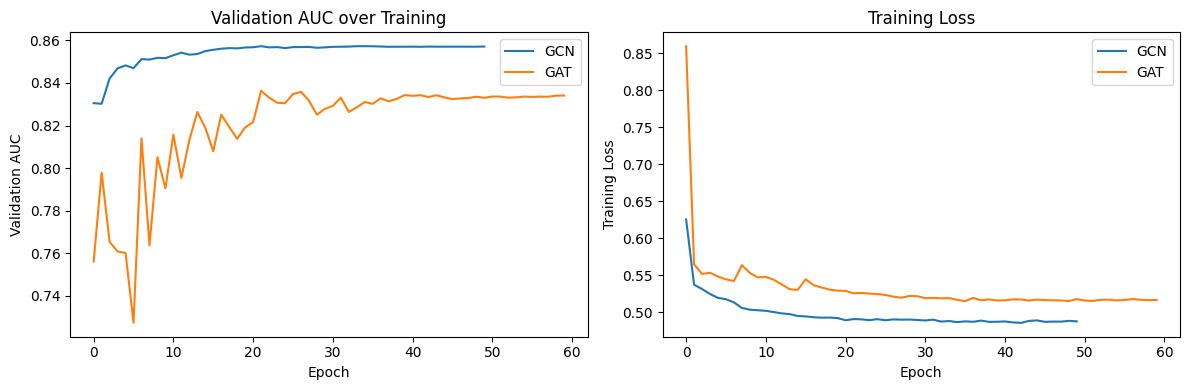

In [22]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(gcn_history['val_auc'], label='GCN')
axes[0].plot(gat_history['val_auc'], label='GAT')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation AUC')
axes[0].legend()
axes[0].set_title('Validation AUC over Training')

axes[1].plot(gcn_history['train_loss'], label='GCN')
axes[1].plot(gat_history['train_loss'], label='GAT')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].legend()
axes[1].set_title('Training Loss')

plt.tight_layout()
plt.savefig('gnn_training_curves.png', dpi=150)
plt.show()

## Task II Results: Graph-Based Quark/Gluon Classification

Graph Construction:

We projected the ParticleNet point cloud data to graphs using 
k-Nearest Neighbors (k=8) in the (η, φ) angular space. This 
approach connects particles that are physically close in the 
detector, reflecting the structure of parton showers.

### Architecture Comparison:

1. GCN (Graph Convolutional Network)
   - 3 layers, hidden_channels=64
   - Uniform neighbor aggregation
   - Test Accuracy: 78.4%, AUC: 0.856

2. GAT (Graph Attention Network)  
   - 3 layers, hidden_channels=64, 4 attention heads
   - Learned attention-weighted aggregation
   - Test Accuracy: 71.7%, AUC: 0.830

### Performance Analysis:

GCN outperformed GAT by 6.7% in accuracy and 2.6% in AUC. 
Possible reasons:

1. GAT's attention mechanism introduces more parameters, 
   requiring more data or training time to converge optimally.

2. The k-NN graph construction already captures relevant local 
   structure, making attention-based weighting less beneficial.

3. In jet physics, particle neighborhoods may be sufficiently 
   uniform that equal aggregation (GCN) works well.

Both models achieve AUC > 0.83, demonstrating that graph-based 
approaches effectively capture jet substructure for quark/gluon 
discrimination.